Nom : Khadijetou Mohamed abe

Filière : GLCC

# 1. CODE SCRATCH

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def distance_euclidienne(p1, p2):
    # """
    # Calcule la distance directe (euclidienne) entre deux points.
    # Formule : √((x2-x1)**2 + (y2-y1)**2)
    # """
    return np.sqrt(np.sum((p1 - p2) ** 2))

def trouver_voisins(data, point_idx, eps):
    # """
    # Retourne les indices de tous les points situés dans le rayon eps d'un point spécifique.
    # """
    voisins =[]

    for i in range(len(data)):
        # Si la distance entre notre point et le point 'i' est inférieure ou égale à eps
        if distance_euclidienne(data[point_idx], data[i]) <= eps:
            # On ajoute l'indice 'i' à la liste des voisins
            voisins.append(i)
    return voisins

def dbscan_scratch(data, eps, MinPts):
    # """
    # eps: Rayon du voisinage autour d'un point donné.
    # MinPts: Nombre minimum de points requis dans le voisinage de rayon eps
    # Algorithme DBSCAN:
    # 0 representer le point non visité (unmarked)
    # -1 <=> bruit (noise point)
    # >0 <=> numéro du cluster (C)
    # """

    #On initialise tous les labels à 0 (unmarked points)
    labels = np.zeros(len(data))
    
    # Initialisation du numéro de cluster (C) à 0
    C = 0
    
    for i in range(len(data)):
        # on parcourt de manière séquentielle, en ignorant ceux déjà marqués
        if labels[i] != 0:
            # Si le label n'est pas 0, il est déjà "marked", on passe au point suivant
            continue
            
        # Sinon, nous le marquerons en lui attribuant un cluster ou le statut de bruit
        # On trouve d'abord les voisins pour X
        voisins_de_X = trouver_voisins(data, i, eps)
        
        # si le nombre de points dans la zone adjacente de rayon eps de X >= MinPts
        if len(voisins_de_X) >= MinPts:
            
            # Créer un nouveau cluster C et placer X dans C
            C += 1           # On incrémente pour créer un nouveau cluster (ex: Cluster 1, 2...)
            labels[i] = C    # On assigne le point X à ce nouveau cluster C
            
            k = 0
            while k < len(voisins_de_X):
                # On extrait l'indice du voisin actuel (x)
                x_idx = voisins_de_X[k]
                
                # Cas spécial : si x avait été préalablement marqué comme bruit (-1)
                # On l'ajoute au cluster, mais on n'explore pas ses voisins (il ne les a pas)
                if labels[x_idx] == -1:
                    labels[x_idx] = C
                    
                # sinon, si x unmarked 
                elif labels[x_idx] == 0:
                    # On marque le point en l'assignant directement au cluster courant C
                    labels[x_idx] = C
                    
                    # On cherche les voisins de ce nouveau point x pour voir s'il est dense
                    voisins_de_x = trouver_voisins(data, x_idx, eps)
                    
                    if len(voisins_de_x) >= MinPts:
                        # On étend notre liste initiale pour continuer l'exploration
                        for v in voisins_de_x:
                            # Pour éviter les doublons infinis, on ajoute seulement s'il n'y est pas
                            if v not in voisins_de_X:
                                voisins_de_X.append(v)
                                
                # On incrémente k pour passer au prochain voisin de la liste 
                k += 1
                
        else:
            # si moins de MinPts, on marque comme bruit avec -1)
            labels[i] = -1
    return labels



## a. DATASET

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
# make_moons génère un ensemble de données en forme de deux demi-lunes entrelacées
# n_samples = nombre de points, noise = niveau de dispersion
X_original, y_original_labels = make_moons(n_samples=300, noise=0.08, random_state=42)

# outil de normalisation
scaler_dbscan = StandardScaler()

# fit_transform calcule la moyenne et l'écart-type et applique la normalisation
# Les données se retrouvent centrées autour de 0.
X_data_dbscan = scaler_dbscan.fit_transform(X_original)

## b. Exécution du code scratch

In [10]:
labels_scratch_dbscan = dbscan_scratch(X_data_dbscan, eps=0.25 , MinPts=5)

## c. Code sklearn

In [11]:
from sklearn.cluster import DBSCAN

# On crée un objet en initialisant la classe DBSCAN de Sklearn avec les mêmes paramètres
modele_sklearn_dbscan = DBSCAN(eps=EPS_VAL, min_samples=MINPTS_VAL)

# fit_predict effectue l'entraînement et retourne directement les prédictions (labels des clusters)
labels_sklearn_dbscan = modele_sklearn_dbscan.fit_predict(X_data_dbscan)

## d. Comparaison et graphiques (scratch/sklearn)

comparaison


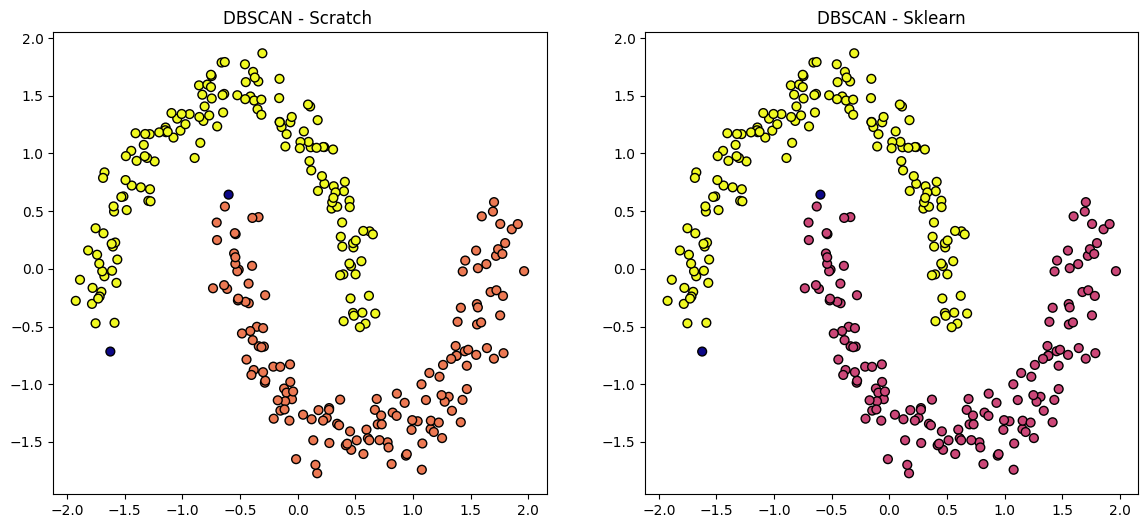

In [14]:

print("comparaison")

plt.figure(figsize=(14, 6))

# Graphique 1 : Scratch
plt.subplot(1, 2, 1) 
scatter_scratch = plt.scatter(X_data_dbscan[:, 0], X_data_dbscan[:, 1], c=labels_scratch_dbscan, cmap='plasma', s=40, edgecolors='k')
plt.title('DBSCAN - Scratch ')

# Graphique 2 : Sklearn
plt.subplot(1, 2, 2) 
scatter_sklearn = plt.scatter(X_data_dbscan[:, 0], X_data_dbscan[:, 1], c=labels_sklearn_dbscan, cmap='plasma', s=40, edgecolors='k')
plt.title('DBSCAN - Sklearn')

plt.show()